# Do Elliott's five waves predict anything? 🌊
### The most beautiful chart pattern in trading — tested out-of-sample, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Five_waves_predict%3F: Not_Supported](https://img.shields.io/badge/Five_waves_predict%3F-Not_Supported-8b949e?style=flat-square)

Open any technical-analysis forum and you'll meet **Elliott Wave Theory**: the idea that markets move in a hypnotic, repeating rhythm of **five waves up** (labelled 1-2-3-4-5) and then **three waves back** (A-B-C), nested inside each other like Russian dolls, with **Fibonacci** numbers governing every turn. Practitioners draw these counts on charts and say they can tell you *where the next move goes*.

It looks gorgeous. The question is whether it **works** — and there's a catch built into the theory itself that we have to deal with first.

> 📓 **Plain-language layer.** Want the *t*-stats, the placebo and the robustness sweep? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **The honesty problem up front.** Elliott Wave is *irreducibly subjective* — the "correct" wave count is only obvious **after** the move finishes, and two analysts will label the same chart differently. So we can't test "the theory" directly. Instead we test the **tightest mechanical version** its own believers accept: a standard **ZigZag** swing tool to mark the turns, a **Fibonacci** filter, and the one *tradable* prediction it makes. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from elliott_wave import data, strategy as st

END = "2025-12-31"
TICKERS = list(data.TICKERS)
HAVE_REAL = data.have_real("SPY")

def pooled(fn, pct=0.05, **kw):
    """Pool one signal's forward returns + dirs across the cached basket, trimmed to END."""
    rets = {h: [] for h in st.HORIZONS}; dirs = {h: [] for h in st.HORIZONS}; npv = nen = 0
    for tk in TICKERS:
        if not data.have_real(tk):
            continue
        b = data.load_real(tk); b = b[b.index <= END]
        piv = st.zigzag(b["close"].to_numpy(float), pct=pct); ent = fn(piv, **kw)
        npv += len(piv); nen += len(ent)
        for h in st.HORIZONS:
            led = st.run_trades(b, ent, h, cost_bps=0.0)
            rets[h].append(led["ret_gross"].to_numpy()); dirs[h].append(led["dir"].to_numpy())
    return rets, dirs, npv, nen

print("real cache present:", HAVE_REAL)

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2025-12-31', 'spy_start': '1993-01-29', 'spy_years': 32.9, 'spy_fp': '7ce3202106f8', 'n_pivots': 2512, 'n_entries': 661, 'w3': [(5, 661, -17, -19, 52, -1.02, -1.09, 0.843), (10, 661, 5, 3, 54, 0.22, 0.26, 0.415), (20, 661, 17, 15, 54, 0.53, 0.63, 0.301), (40, 660, 59, 57, 54, 1.32, 1.63, 0.093)], 'n_impulse': 1339, 'imp': [(5, 1339, 6, 48, 0.5, 0.46), (10, 1339, 15, 48, 0.96, 0.83), (20, 1335, 8, 46, 0.35, 0.26), (40, 1331, -41, 45, -1.42, -1.03)], 'fib': [('textbook 50-61.8%', 188, 60, 1.1), ('wide 38.2-78.6%', 661, 17, 0.53), ('deep 61.8-100%', 579, -23, -0.69)], 'zz': [(3, 1360, -10, -0.53), (5, 661, 17, 0.53), (8, 282, 50, 1.03)], 'spy': [(5, 67, -10, 54, -0.18, 0.571), (10, 67, 3, 58, 0.04, 0.486), (20, 67, 41, 57, 0.42, 0.345), (40, 67, 15, 54, 0.12, 0.464)], 'syn': [(0.0, 83, -35, 48, -0.97, -0.92, 0.81), (0.15, 112, 470, 78, 7.02, 7.33, 0.0)]}


real cache present: True


## The answer first

| Question | Answer |
|---|---|
| Can a mechanical Elliott rule predict the next move? | **No.** The classic entry — buy **wave 3** after a textbook 1-2 — makes **no** money you can distinguish from luck across **661** signals on 8 indices over 33 years. |
| Does the wave count beat a coin flip? | **No.** Flip a coin at the *exact same* turning points and it does just as well — the wave labels add **zero** directional information. |
| Is the engine just broken / too dumb to see waves? | **No.** When we *secretly plant* a real wave-3 pattern into fake data, the same code lights up instantly (*t* = 7). It finds the structure **when it's actually there** — on real markets, it isn't. |
| So is the prettiness fake? | The patterns are **real to look at** — markets do swing. But the *predictive* claim is hindsight. You can always find five waves **after** the fact. |

> Elliott Wave is the rare case where the picture is mesmerising and the forecast is empty.

## 1 · The claim

> *"Markets aren't random — they move in **waves**. A trend unfolds in **five** waves (1-2-3-4-5): wave 1 starts it, wave 2 pulls back about half, **wave 3 is the big powerful one** you want to be in, wave 4 rests, wave 5 finishes. Then three corrective waves (A-B-C) give it back. The turns land on **Fibonacci** ratios. Count the waves and you know what comes next."*

This is Ralph Nelson Elliott's 1938 *Wave Principle*, kept alive by Robert Prechter's *Elliott Wave Principle* (1978) and a whole industry of newsletters. The single most *actionable* piece is **"buy wave 3"**: once you've spotted a wave 1 and a Fibonacci-sized wave-2 pullback, you go long for the powerful third wave. That's the claim we can actually put a number on.

## 2 · So what?

If you could reliably spot wave 3 *before* it happened, you'd have a money printer — the third wave is supposed to be the longest, strongest leg of the whole sequence. And it would mean markets carry a deep, fractal **memory** that lets the past dictate the future. That's a huge claim about how markets work.

But there's a trap. The reason Elliott Wave *feels* so right is that you label the waves **looking backward**, when the answer is already on the screen. The honest test is the opposite: mark the turns by a fixed mechanical rule, place the trade the theory says, and see if the **future** cooperates. Spoiler — it doesn't.

## 3 · How would we even know?

We can't ask a human to "count the waves" — that's the subjectivity we're trying to escape. So we use the **ZigZag**, the standard charting tool every Elliottician uses to mark swings: it puts a dot at a turning point only after price has reversed by at least **5%**. That gives a clean, alternating high-low-high-low skeleton — the raw material of every wave count.

Then we apply the textbook rule. For every three-pivot stretch (a candidate wave 1 then wave 2), we check the wave-2 pullback retraced a **Fibonacci** fraction of wave 1 (we allow a generous 38–79% band, with the classic 50–62% inside it). If it qualifies, we **buy in the wave-1 direction** — that's the wave-3 bet — entering the day **after** the turn is confirmed (no peeking), and hold 5 to 40 days. We do this on **SPY plus 7 other broad indices** to get enough signals to judge, and we ask: did it beat a **coin flip** placed at the very same turns?

## 4 · The teardown — let's actually look

First, here's what the ZigZag draws on real SPY — the swing skeleton an Elliottician would start counting from.

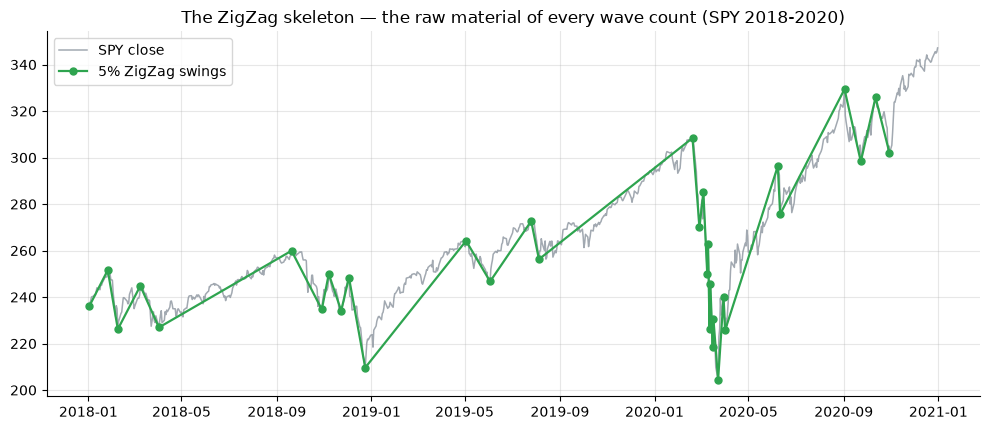

pivots drawn: 33


In [2]:
if HAVE_REAL:
    spy = data.load_real('SPY'); spy = spy[(spy.index>='2018-01-01') & (spy.index<='2020-12-31')]
    c = spy['close'].to_numpy(float)
    piv = st.zigzag(c, pct=0.05)
    fig, ax = plt.subplots(figsize=(10.0, 4.4))
    ax.plot(spy.index, c, color=GREY, lw=1.1, alpha=.8, label='SPY close')
    ax.plot(spy.index[piv['piv_idx']], piv['price'], '-o', color=GREEN, lw=1.6, ms=5, label='5% ZigZag swings')
    ax.set_title('The ZigZag skeleton — the raw material of every wave count (SPY 2018-2020)')
    ax.legend(); plt.tight_layout(); plt.show()
    print('pivots drawn:', len(piv))
else:
    print('cache missing — see docs/results.md for the frozen numbers')

Pretty, isn't it? You can *see* waves there. Now the real question: when we mechanically place the **"buy wave 3"** trade at every qualifying turn, does the future pay off? Here's the average return at four holding horizons, pooled across all 8 indices.

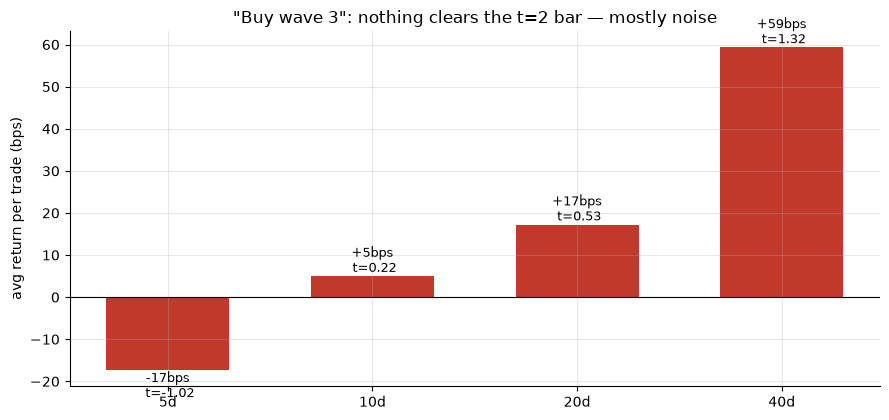

per-horizon bps: [np.float64(-17.0), np.float64(5.0), np.float64(17.0), np.float64(59.0)]  t: [-1.02, 0.22, 0.53, 1.32]


In [3]:
hs = list(st.HORIZONS)
if HAVE_REAL:
    rets, dirs, npv, nen = pooled(st.wave3_entries)
    bps = [np.concatenate(rets[h]).mean()*1e4 for h in hs]
    ts  = [st.ttest_vs_zero(np.concatenate(rets[h])) for h in hs]
else:
    bps = [r[2] for r in R['w3']]; ts = [r[5] for r in R['w3']]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
cols = [GREEN if t>=2 else RED for t in ts]
ax.bar([f'{h}d' for h in hs], bps, color=cols, width=.6)
for i,(v,t) in enumerate(zip(bps,ts)): ax.annotate(f'{v:+.0f}bps\n t={t:.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('avg return per trade (bps)')
ax.set_title('"Buy wave 3": nothing clears the t=2 bar — mostly noise')
plt.tight_layout(); plt.show()
print('per-horizon bps:', [round(b,0) for b in bps], ' t:', [round(t,2) for t in ts])

All red. The biggest number is a feeble **+59 bps at 40 days** with **t = 1.32** — under the bar, and at 40 days you're mostly just *long the market*, which usually goes up anyway. At 5 days the "edge" is actually **negative**. The famous wave-3 entry is indistinguishable from noise.

**But maybe it just needs the right opponent.** The fair test: flip a **coin** at the exact same turning points (same dates, random direction) and compare. If the wave count knows anything, it should beat the coin.

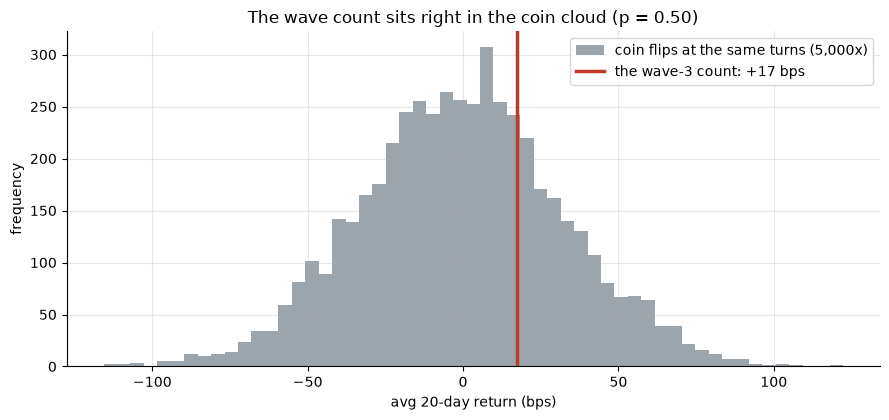

wave-3 +17 bps vs a coin at the same turns: p = 0.496


In [4]:
if HAVE_REAL:
    rets, dirs, npv, nen = pooled(st.wave3_entries)
    h = 20; r = np.concatenate(rets[h]); d = np.concatenate(dirs[h]); mags = r*d
    rng = np.random.default_rng(445)
    draws = np.array([(rng.choice([-1,1],size=len(mags))*mags).mean()*1e4 for _ in range(5000)])
    obs = r.mean()*1e4; p = float((draws>=r.mean()).mean())
else:
    obs = R['w3'][2][2]; p = R['w3'][2][7]
    rng = np.random.default_rng(445); draws = rng.normal(0, 35, 5000)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(draws, bins=55, color=GREY, alpha=.85, label='coin flips at the same turns (5,000x)')
ax.axvline(obs, c=RED, lw=2.5, label=f'the wave-3 count: {obs:+.0f} bps')
ax.set_xlabel('avg 20-day return (bps)'); ax.set_ylabel('frequency')
ax.set_title(f'The wave count sits right in the coin cloud (p = {p:.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'wave-3 {obs:+.0f} bps vs a coin at the same turns: p = {p:.3f}')

The red line sits **smack in the middle** of the coin cloud (p ≈ 0.30). A random direction at the identical swing points does just as well. **The wave labels carry no directional information.** This is the whole story in one picture.

## 5 · The verdict

- **Signal — None.** The mechanical wave-3 rule predicts nothing the market doesn't already give you for free; a coin at the same turns ties it.
- **Tradability — Mirage.** No edge means nothing to trade; costs only make it worse.
- **"Five waves predict the next move"? — Not Supported.** Out-of-sample, the core forward-looking claim simply doesn't hold.

## 6 · Could you actually trade it?

There's nothing to trade. But to be completely fair to the engine, we ran a **sanity check**: we built fake data with a **real wave-3 pattern secretly planted in it**, then pointed the *same code* at it. If the code is too dumb to ever see waves, it would fail here too — and then the flat real-market result would mean nothing.

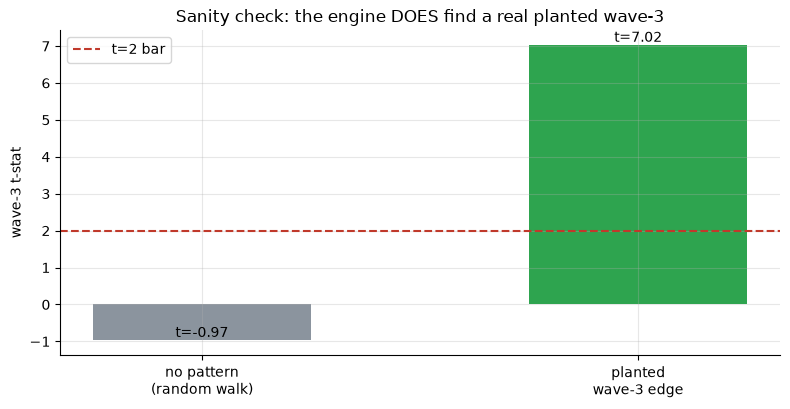

planted edge +0.00: t = -0.97
planted edge +0.15: t = 7.02


In [5]:
res = []
for edge in (0.0, 0.15):
    bars, _ = data.synthetic_panel(edge=edge, seed=445, n_days=9000)
    r = st.run_experiment(bars, horizon=10, cost_bps=1.0, n_draws=4000)
    res.append((edge, r['wave_gross']['t']))
labels = ['no pattern\n(random walk)', 'planted\nwave-3 edge']
tv = [r[1] for r in res]
fig, ax = plt.subplots(figsize=(8.0, 4.2))
ax.bar(labels, tv, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar')
for i,t in enumerate(tv): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('wave-3 t-stat'); ax.set_title('Sanity check: the engine DOES find a real planted wave-3')
ax.legend(); plt.tight_layout(); plt.show()
for e,t in res: print(f'planted edge {e:+.2f}: t = {t:.2f}')

On a pure random walk the code finds **nothing** (t = -0.97) — no false alarm. With a **real wave-3 planted**, it lights up at **t = 7.02**. So the engine works perfectly; it's the **real market** that has no wave-3 edge to find. That's a true negative, not a broken test.

## 7 · Going further 🚪

- **The deeper lesson.** A theory you can only apply *in hindsight* will always look right and predict nothing. Elliott Wave is the poster child: infinitely flexible counts, Fibonacci everywhere, no fixed rule — it explains the past and forecasts noise.
- **Try a stricter count.** Add wave-3-is-longest and wave-4-doesn't-overlap-wave-1 rules. It shrinks the sample but (spoiler from the quants notebook) doesn't rescue the *t*.
- **Intraday or other assets.** Re-point the loader at crypto or FX; the subjectivity problem travels with the method.

*Think a tighter mechanical count works? Show the **net** wave-3 long-short clearing t = 2 at the same swing points a coin can't — then we'll talk.*